In [1]:
# моделирование случайных блужданий
# броуновской частицы
# на одномерной решетке с ловушками
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

In [ ]:
# Ячейка № 2

# задание функции, возвращающей значения
# зависимости времени жизни броуновской частицы
# от значения ее начальной координаты
def Time(N_trial, p, Ns, a):
    # N_trial - число испытаний
    # p - пороговое значение вероятности перехода
    # Ns - количество начальных точек

    # инициализация массива Nt,
    # используемого для хранения
    # значения времени жизни
    # броуновской частицы,
    # находящейся в начальный
    # времени в соответствующей точке,
    # на каждом шаге методаМонте-Карло
    Nt = np.zeros(N_trial + 1)

    # инициализация массива X,
    # используемого для хранения
    # координаты броуновской частицы
    # в момент времени t = 0
    X = np.zeros(Ns)

    # инициализация массива t,
    # используемого для хранения
    # усредненных по ансамблю реализаций
    # значений времени жизни
    # броуновской частицы
    t = np.zeros(Ns)

    # вычисление шага изменения
    # начальной координаты
    # броуновской частицы
    dx = a / (Ns + 1)

    # вычисление для заданных
    # начальных координат
    # соответствующих усредненных
    # по ансамблю реализаций
    # значений времени жизни
    # броуновской частицы
    for m in range(Ns):
        # m - номер начальной точки
        i = 0
        while i <= N_trial:
            # i - номер шага метода Монте -Карло
            j = 0
            # вычисление координаты
            # броуновской частицы в момент времени t = 0
            x = dx * (m + 1)
            # вычисление числа шагов, совершенных
            # броуновской частицей до достижения
            # ею узла-ловушки на i-ом шаге
            # метода Монте-Карло
            while (x < a) & (x > 0):
                if p > random.uniform(0, 1):
                    x = x + 1
                else:
                    x = x - 1
                j = j + 1
            # сохраняем значение числа шагов,
            # совершенных броуновской частицей до достижения
            # ею узла-ловушки на i-ом шаге
            # метода Монте-Карло
            Nt[i] = j
            i = i + 1
        # сохраняем значение координаты броуновской частицы
        # в момент времени t = 0
        X[m] = dx * (m + 1)
        # сохраняем усредненное по ансамблю
        # реализаций значение времени жизни
        # броуновской частицы
        t[m] = np.mean(Nt)
    return X, t

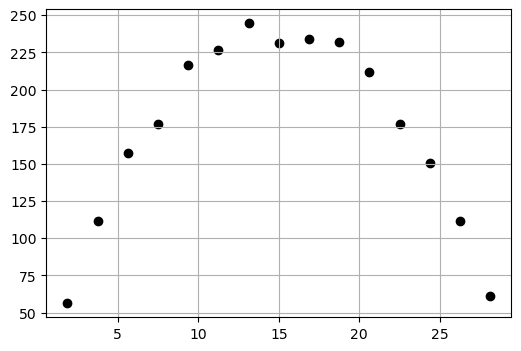

In [3]:
# Ячейка № 3

# инициализация генератора случайных чисел
random.seed()

# задание числа шагов метода Монте-Карло
N_trial = 2 * 10**3

# задание количества вычисляемых
# значений зависимости
# времени жизни броуновской частицы
# от начальной координаты
Ns = 15

#  расстояние между узлами-ловушками
a = 30

# вычисление значений зависимости
# времени жизни броуновской частицы
# от начальной координаты
[X, T] = Time(N_trial, 0.5, Ns, a)

# визуализация значений зависимости
# времени жизни броуновской частицы
# от начальной координаты

fig = plt.figure(figsize=(6, 4))
plt.scatter(X, T, c="black")
ax = fig.gca()
ax.grid(True)

plt.show()